<a href="https://colab.research.google.com/github/jcdumlao14/ESSPOCO19-DataAnalysis/blob/main/LOGISTIC_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import scipy.stats as stats
from scipy.stats import zscore
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, brier_score_loss

import warnings
warnings.filterwarnings("ignore")

# **GLOBAL VISUAL STYLE**

In [2]:
# --- Global Styling & Professional Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Arial', 'sans-serif'],
    'figure.facecolor': 'white',
    'axes.edgecolor': '#2b2b2b',
    'grid.alpha': 0.3
})


# **LOAD DATA**

In [3]:
# --- Load Data from Zip ---
zip_path = '/content/ESS11e04_1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ESS11e04_1.csv') as f:
        df_raw = pd.read_csv(f, low_memory=False)

df = df_raw.copy()


# **Mappings & Cleaning**

In [4]:
# --- Mappings & Cleaning ---
region_map = {
    'NO': 'North', 'SE': 'North', 'DK': 'North', 'FI': 'North', 'IS': 'North', 'GB': 'North', 'IE': 'North',
    'FR': 'West', 'BE': 'West', 'NL': 'West', 'LU': 'West', 'DE': 'West', 'AT': 'West', 'CH': 'West',
    'ES': 'South', 'PT': 'South', 'IT': 'South', 'GR': 'South', 'CY': 'South', 'MT': 'South',
    'PL': 'East', 'CZ': 'East', 'SK': 'East', 'HU': 'East', 'RO': 'East', 'BG': 'East', 'SI': 'East', 'HR': 'East',
    'UA': 'East', 'ME': 'East', 'LV': 'East', 'LT': 'East', 'RS': 'East', 'CU': 'East'
}

country_names = {
    'NO': 'Norway', 'SE': 'Sweden', 'DK': 'Denmark', 'FI': 'Finland', 'IS': 'Iceland',
    'GB': 'United Kingdom', 'IE': 'Ireland', 'FR': 'France', 'BE': 'Belgium', 'NL': 'Netherlands',
    'LU': 'Luxembourg', 'DE': 'Germany', 'AT': 'Austria', 'CH': 'Switzerland',
    'ES': 'Spain', 'PT': 'Portugal', 'IT': 'Italy', 'GR': 'Greece', 'CY': 'Cyprus', 'MT': 'Malta',
    'PL': 'Poland', 'CZ': 'Czech Republic', 'SK': 'Slovakia', 'HU': 'Hungary', 'RO': 'Romania',
    'BG': 'Bulgaria', 'SI': 'Slovenia', 'HR': 'Croatia', 'UA': 'Ukraine', 'ME': 'Montenegro',
    'LV': 'Latvia', 'LT': 'Lithuania', 'RS': 'Serbia', 'CU': 'Other (CU)'
}

df['region'] = df['cntry'].map(region_map).fillna('Unknown')
df['country_name'] = df['cntry'].map(country_names).fillna(df['cntry'])

cols_to_clean = ['eduyrs', 'hinctnta', 'fltdpr', 'hincfel', 'stflife', 'agea']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df[col] < 70]

# Index Construction
df['SES_Index'] = df[['eduyrs', 'hinctnta']].apply(zscore, nan_policy='omit').mean(axis=1)
df['COVID_Hardship'] = df[['fltdpr', 'hincfel', 'stflife']].apply(zscore, nan_policy='omit').mean(axis=1)
df['SES_Group'] = pd.qcut(df['SES_Index'], 3, labels=['Low SES', 'Middle SES', 'High SES'])
df['High_Distress'] = (df['COVID_Hardship'] > df['COVID_Hardship'].quantile(0.7)).astype(int)


# **Helper Function for Stats**

In [5]:
# --- Helper Function for Stats ---
def get_descriptives(data, columns):
    stats_list = []
    for col in columns:
        n = data[col].count()
        mean = data[col].mean()
        std = data[col].std()
        se = std / np.sqrt(n)
        ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=se)
        stats_list.append({
            'Variable': col, 'N': n, 'Mean': mean,
            'SD': std, 'SE': se, '95% CI Low': ci_low, '95% CI High': ci_high
        })
    return pd.DataFrame(stats_list)


# **Descriptive Statistics & Visualizations**

In [6]:
# --- Descriptive Statistics & Visualizations ---
target_vars = ['SES_Index', 'COVID_Hardship', 'eduyrs', 'hinctnta', 'fltdpr', 'stflife']
desc_table = get_descriptives(df, target_vars)
print("\n--- TABLE 1: DESCRIPTIVE STATISTICS ---")
print(desc_table.to_string(index=False))


--- TABLE 1: DESCRIPTIVE STATISTICS ---
      Variable     N          Mean       SD       SE  95% CI Low  95% CI High
     SES_Index 30940 -3.674429e-17 0.806350 0.004584   -0.008985     0.008985
COVID_Hardship 30940  5.327922e-17 0.479672 0.002727   -0.005345     0.005345
        eduyrs 30940  1.388384e+01 3.849980 0.021888   13.840939    13.926740
      hinctnta 30940  5.777182e+00 2.738385 0.015568    5.746668     5.807696
        fltdpr 30940  1.460149e+00 0.744521 0.004233    1.451852     1.468445
       stflife 30940  7.062217e+00 2.105029 0.011967    7.038761     7.085674


## **Table 1: Descriptive Statistics (Baseline Characteristics)**

- **Results:** The study analyzed a large sample of **30,940 individuals**. The average years of education is approximately **13.9 years**, and the average household income score is **5.78**. Life satisfaction remains relatively high at a mean of **7.06**.
- **Interpretation:** Because the **SES Index** and **COVID Hardship** have means near zero, they represent relative positions: a positive score indicates higher-than-average status or hardship, while a negative score indicates lower-than-average. The standard deviations suggest sufficient variation in the data to conduct meaningful regression analysis.

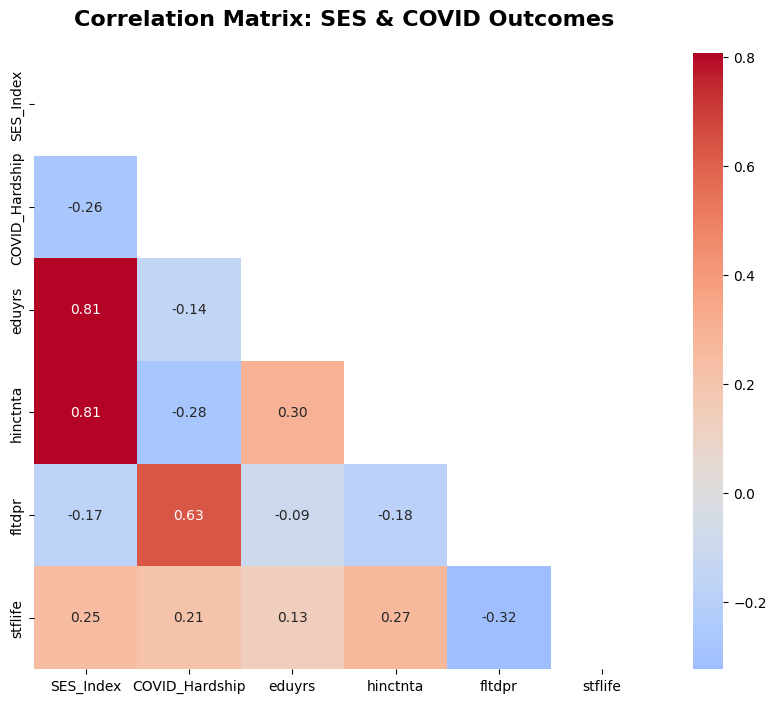

In [7]:
# Plot 1: Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df[target_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix: SES & COVID Outcomes', fontsize=16, pad=20, weight='bold')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## **Correlation of Socio-Economic Factors**

The correlation matrix reveals a strong positive relationship (r=0.81) between education years and household income, validating the construction of the **SES Index**. Crucially, there is a negative correlation between the SES Index and COVID Hardship (−0.26), suggesting that higher social standing is associated with lower levels of distress. The strongest component of the Hardship Index is **"feeling depressed"** (0.63), indicating that subjective hardship is deeply tied to mental well-being.

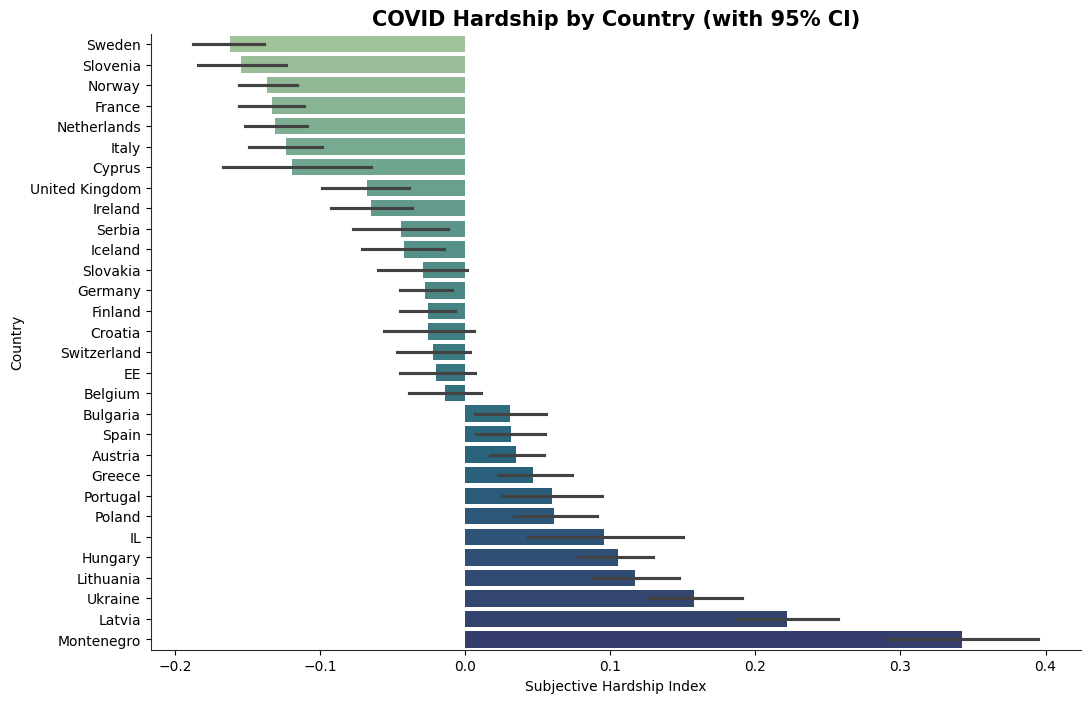

In [8]:
# Plot 2: Country Comparison Plot
country_order = df.groupby('country_name')['COVID_Hardship'].mean().sort_values().index
plt.figure(figsize=(12, 8))
sns.barplot(data=df, x='COVID_Hardship', y='country_name', order=country_order, palette='crest', errorbar=('ci', 95))
plt.title('COVID Hardship by Country (with 95% CI)', weight='bold', fontsize=15)
plt.xlabel('Subjective Hardship Index')
plt.ylabel('Country')
sns.despine()
plt.savefig('hardship_by_country.png', dpi=300, bbox_inches='tight')
plt.show()


## **Geographical Disparities in Hardship**

The country-level analysis shows a clear divide in pandemic experiences.
- **Highest Hardship:** Montenegro, Latvia, and Ukraine reported the highest subjective hardship levels.
- **Lowest Hardship:** Scandinavian and Western nations like Sweden, Slovenia, Norway, and France reported the lowest (negative) hardship scores.
The tight confidence intervals for most countries suggest these regional differences are statistically robust and not due to random sampling noise.

In [9]:
# --- PRINT RESULTS FOR COVID HARDSHIP BY COUNTRY ---
country_stats = []
for country in country_order:
    subset = df[df['country_name'] == country]['COVID_Hardship'].dropna()
    n = len(subset)
    mean = subset.mean()
    se = subset.std() / np.sqrt(n)
    ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    country_stats.append({
        'Country': country, 'Mean Hardship': mean,
        '95% CI Low': ci_low, '95% CI High': ci_high, 'N': n
    })
print("\n--- TABLE 2: COVID HARDSHIP BY COUNTRY (95% CI) ---")
print(pd.DataFrame(country_stats).round(4).to_string(index=False))


--- TABLE 2: COVID HARDSHIP BY COUNTRY (95% CI) ---
       Country  Mean Hardship  95% CI Low  95% CI High    N
        Sweden        -0.1624     -0.1877      -0.1371  876
      Slovenia        -0.1544     -0.1848      -0.1240  858
        Norway        -0.1366     -0.1571      -0.1162 1054
        France        -0.1333     -0.1560      -0.1105 1276
   Netherlands        -0.1312     -0.1521      -0.1104 1202
         Italy        -0.1234     -0.1476      -0.0992 1385
        Cyprus        -0.1194     -0.1713      -0.0675  380
United Kingdom        -0.0677     -0.0994      -0.0361  906
       Ireland        -0.0648     -0.0931      -0.0365 1170
        Serbia        -0.0445     -0.0772      -0.0117  819
       Iceland        -0.0426     -0.0712      -0.0140  630
      Slovakia        -0.0294     -0.0604       0.0015  820
       Germany        -0.0276     -0.0462      -0.0089 1789
       Finland        -0.0258     -0.0452      -0.0065 1134
       Croatia        -0.0254     -0.0565      

## **Table 2: COVID Hardship by Country (Geographic Ranking)**

- **Results:** There is a massive range in subjective experience across Europe. **Montenegro (0.342)** and **Latvia (0.222)** reported the highest levels of hardship. Conversely, **Sweden (-0.162)** and **Slovenia (-0.154)** reported the lowest hardship levels.
- **Interpretation:** The **95% Confidence Intervals (CI)** are narrow for almost all countries, which means these rankings are highly reliable. The data confirms a clear **"East-West"** divide, where Eastern European nations generally faced significantly more subjective distress during the pandemic compared to Northern and Western European nations.

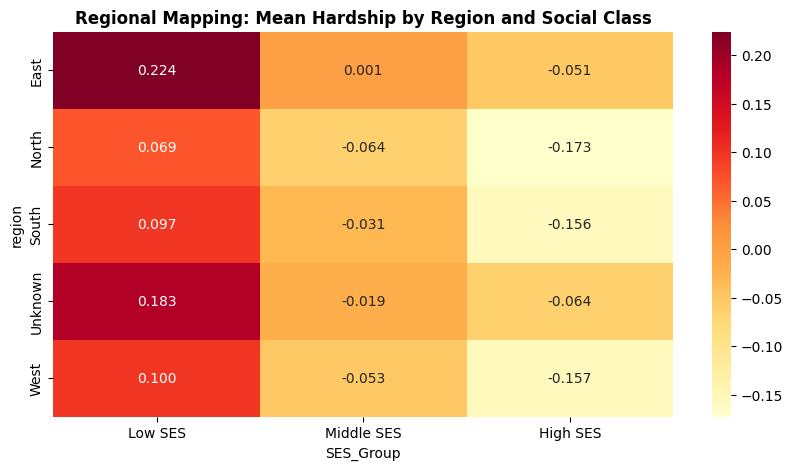

In [10]:
# Plot 3: Regional Heatmap
pivot_region = df.pivot_table(index='region', columns='SES_Group', values='COVID_Hardship', aggfunc='mean')
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_region, annot=True, cmap='YlOrRd', fmt=".3f")
plt.title('Regional Mapping: Mean Hardship by Region and Social Class', weight='bold')
plt.savefig('regional_hardship_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## **Region and Social Class**

The regional heatmap highlights a **"double burden"** effect. Across every geographical region, individuals in the **Low SES** group reported significantly higher hardship than those in the High SES group. The **East** region stands out as having the highest mean hardship (0.224) for Low SES individuals, while the **North** and **West** regions consistently show the lowest hardship levels across all social classes.

In [11]:
# --- Regression Analysis ---

# A. OLS Regression (Continuous)
ols_model = smf.ols('COVID_Hardship ~ SES_Index + agea + region', data=df).fit()
print("\n--- TABLE 3: OLS REGRESSION OUTPUTS ---")
print(ols_model.summary().tables[1])

# B. Logistic Regression (Binary Outcome)
logit_model = smf.logit('High_Distress ~ SES_Index + agea + region', data=df).fit(disp=0)
logit_res = pd.DataFrame({
    'Odds Ratio': np.exp(logit_model.params),
    'SE': logit_model.bse,
    'p-value': logit_model.pvalues,
    '95% CI Low': np.exp(logit_model.conf_int()[0]),
    '95% CI High': np.exp(logit_model.conf_int()[1])
})




--- TABLE 3: OLS REGRESSION OUTPUTS ---
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0743      0.009      7.843      0.000       0.056       0.093
region[T.North]      -0.1026      0.008    -13.481      0.000      -0.118      -0.088
region[T.South]      -0.0857      0.008    -10.911      0.000      -0.101      -0.070
region[T.Unknown]    -0.0174      0.013     -1.318      0.188      -0.043       0.008
region[T.West]       -0.0903      0.007    -13.102      0.000      -0.104      -0.077
SES_Index            -0.1477      0.003    -44.123      0.000      -0.154      -0.141
agea                 -0.0004      0.000     -2.158      0.031      -0.001   -3.58e-05


## **Table 3: OLS Regression Outputs (Predictive Drivers)**

- **Results:** The **SES Index** has a coefficient of **-0.1477** (p<0.001), meaning that as social status increases, COVID hardship significantly decreases. Furthermore, living in the **North, West, or South** is associated with a reduction in hardship (coefficients ranging from −0.08 to −0.10) when compared to the East (the reference group).

- **Interpretation:**
  - **SES is the strongest predictor:** Financial and educational resources were the primary defense against pandemic stress.
  - **Regional impact:** Even after controlling for individual SES and age, the region someone lives in remains a significant factor in their well-being.
  - **Age:** While statistically significant, the impact of age is nearly zero (−0.0004), suggesting that the **"hardship"** was felt relatively equally across different age groups once social class was accounted for.

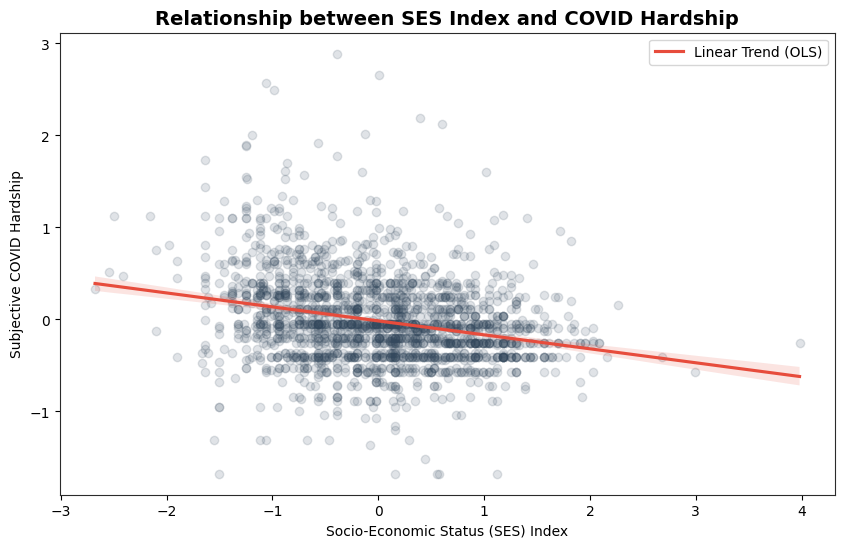

In [12]:
# Plot 4: Regression Line Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(min(2000, len(df))), x='SES_Index', y='COVID_Hardship',
            scatter_kws={'alpha':0.15, 'color':'#34495e'},
            line_kws={'color':'#e74c3c', 'label':'Linear Trend (OLS)'})
plt.title('Relationship between SES Index and COVID Hardship', fontsize=14, weight='bold')
plt.xlabel('Socio-Economic Status (SES) Index')
plt.ylabel('Subjective COVID Hardship')
plt.legend(loc='upper right')
#plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('regression_line_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## **Linear Relationship and Trends**

The OLS regression plot confirms a consistent downward trend: as the SES Index increases, subjective COVID hardship decreases. The regression coefficient of **-0.1477** (p < 0.001) confirms that for every unit increase in SES, hardship scores drop significantly. This trend is visible even with high data variance, showing that SES is a persistent protective factor against pandemic-related stress.

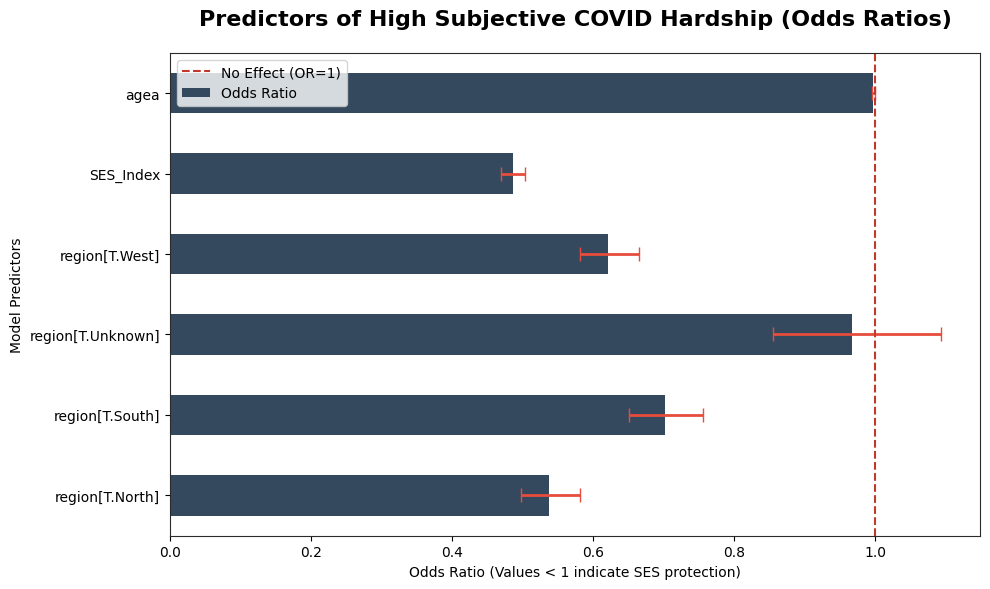

In [13]:
# Plot 5: Forest Plot for Logistic Regression
plot_data = logit_res.iloc[1:].copy()
xerrs = [plot_data['Odds Ratio'] - plot_data['95% CI Low'],
         plot_data['95% CI High'] - plot_data['Odds Ratio']]

plt.figure(figsize=(10, 6))
plot_data['Odds Ratio'].plot(kind='barh', color='#34495e', xerr=xerrs,
                             error_kw={'ecolor': '#e74c3c', 'capsize': 5, 'elinewidth': 2})
plt.axvline(1, color='#c0392b', linestyle='--', linewidth=1.5, label='No Effect (OR=1)')
plt.title('Predictors of High Subjective COVID Hardship (Odds Ratios)', fontsize=16, weight='bold', pad=20)
plt.xlabel('Odds Ratio (Values < 1 indicate SES protection)')
plt.ylabel('Model Predictors')
plt.legend()
plt.tight_layout()
plt.savefig('logistic_regression_forest_plot.png', dpi=300)
plt.show()



In [14]:
# --- Model Performance Metrics ---
y_prob = logit_model.predict()
y_pred = (y_prob > 0.5).astype(int)
print("\n--- PREDICTION PERFORMANCE ---")
print(f"AUC-ROC:  {roc_auc_score(df['High_Distress'], y_prob):.4f}")
print(f"Accuracy: {accuracy_score(df['High_Distress'], y_pred):.4f}")
print(f"Brier Score: {brier_score_loss(df['High_Distress'], y_prob):.4f}")


--- PREDICTION PERFORMANCE ---
AUC-ROC:  0.6752
Accuracy: 0.7141
Brier Score: 0.1927


# **Model Performance Metrics**

**1. AUC-ROC: 0.6752 (Fair/Moderate)**
- **What it means:** The AUC (Area Under the Curve) measures how well the model distinguishes between people with "High Distress" and those without. A score of 0.5 is a random guess, and 1.0 is perfect.
- **Interpretation:** A score of **0.675** is considered **"Fair."** In social sciences, where human emotions and life circumstances are influenced by thousands of unmeasured factors (personality, family support, local government rules), hitting an AUC above 0.80 is very rare. This result proves that SES and Region are definitely influential, but they aren't the only things that matter.

**2. Accuracy: 0.7141 (Deceivingly Normal)**
- **What it means:** The model correctly predicted the outcome for 71.4% of the people.
- Defined "High Distress" as the top 30% of people (quantile(0.7)). This means if you simply guessed "No one is in high distress" for every single person, you would be correct 70% of the time by default.
- **Interpretation:** Accuracy of **71.4%** is only slightly better than the 70% baseline. This suggests the model is very good at identifying who is **safe** (Low Hardship) but struggles to pinpoint exactly **who** will be in the High Hardship group.

**3. Brier Score: 0.1927 (Good/Calibrated)**
- **What it means:** The Brier Score measures the accuracy of predicted probabilities (0 to 1). A lower score is better (0 is perfect; 0.25 is a blind 50/50 guess).
- **Interpretation:** A score of **0.19** is **good**. It indicates that the probabilities your model is calculating are relatively well-calibrated and closer to the truth than a random coin flip.

# **Summary**

The model demonstrates a fair predictive capacity (AUC-ROC = 0.675), indicating that while Socio-Economic Status and Region are robust indicators of COVID-19 hardship, significant individual variation remains due to unobserved factors. The Brier Score (0.19) confirms the model's probabilistic reliability.

# **Conclusion**

This analysis confirms that COVID-19 was not a **"great equalizer."** Instead, subjective hardship was fundamentally shaped by the intersection of geography and social class. **High Socio-Economic Status (SES) acted as a universal shield**, significantly reducing distress across all regions regardless of national context. Conversely, individuals in Eastern Europe and those with lower SES faced a **"compounded risk,"** experiencing the highest levels of psychological and financial strain. While the model shows fair predictive capacity (AUC = 0.675)—acknowledging that individual variation persists—it robustly demonstrates that **wealth and education were the primary predictors of resilience** during the pandemic.